# Tutorial 4: Unstructured Pruning on Bert

Pruning is a technique used to reduce the size and complexity of neural networks by removing unnecessary parameters (weights and connections) or structural components (neurons, filters, or layers). The goal is to create a smaller, more efficient model that maintains most of the original model's performance. The following benefits can be seen from pruning neural networks:

- **Reduce model size**: Deep neural networks often have millions of parameters, leading to large storage requirements.

- **Decrease inference time**: Fewer parameters mean fewer computations, resulting in faster predictions.

- **Improve generalization**: Removing unnecessary connections can help prevent overfitting.

- **Energy efficiency**: Smaller models require less energy to run, which is crucial for edge devices and mobile applications.

Structured pruning removes entire structures (e.g., channels, filters, or layers) from the network, while unstructured pruning removes individual weights or connections from the network, regardless of their location. In this tutorial, we'll build on top of Tutorial 3 by taking the quantized Bert model and running Mase's unstructured pruning pass. After pruning, we'll run further fine tuning iterations to retain sequence classification accuracy in the pruned model.

In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [10]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/bert-tiny.
/Users/yz10513/anaconda3/envs/mase/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


If you have previously ran the tutorial on Quantization-Aware Training (QAT), run the following cell to import the fine tuned checkpoint.

In [2]:
from pathlib import Path
from chop import MaseGraph

mg = MaseGraph.from_checkpoint("/workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_best_fixpoint8_qat")

## Unstructured Pruning

Before running pruning, let's evaluate the model accuracy on the IMDb dataset. If you're coming from Tutorial, this would be the same as the accuracy after Quantization Aware Training (QAT). If you've just initialized the model, this will likely be a random guess (i.e. around 50%), in which case pruning wouldn't have a significant effect on the accuracy.

In [3]:
from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

/workspace/mase-tools/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.84108


To run the pruning pass, we pass the following pruning configuration dictionary, which defines the following parameters.

- **Sparsity**: a value between 0 and 1, expressing the proportion of elements in the model that should be pruned (i.e. set to 0).

- **Method**: several pruning methods are supported, including ``Random`` and ``L1-Norm``.

- **Scope**: defines whether to consider each weight/activation tensor individually (``local``) or all tensors in the model (``global``) when obtaining statistics for pruning (e.g. absolute value threshold for pruning)

We'll start by running random pruning with local scope, at a fixed sparsity. This may be suboptimal, but in future tutorials we'll see how to find optimal pruning and quantization configurations for a given model on a specified dataset.

In [4]:
import chop.passes as passes

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

mg, _ = passes.prune_transform_pass(mg, pass_args=pruning_config)

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Let's evaluate the effect of pruning on accuracy. It's likely to observe drops of around 10% or more.

In [5]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
    num_train_epochs=5,
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/workspace/mase-tools/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.74492


To overcome the drop in accuracy, we'll run a few finetuning epochs. This allows the model to adapt to the new pruning mask.

In [6]:
trainer.train()

Step,Training Loss
500,0.442900
1000,0.414400
1500,0.430800
2000,0.411700
2500,0.409400
3000,0.422000
3500,0.424500
4000,0.411800
4500,0.396100
5000,0.396500


TrainOutput(global_step=15625, training_loss=0.39839207470703125, metrics={'train_runtime': 442.7551, 'train_samples_per_second': 282.323, 'train_steps_per_second': 35.29, 'total_flos': 0.0, 'train_loss': 0.39839207470703125, 'epoch': 5.0})

Let's evaluate the model accuracy after finetuning. We should see that the accuracy is reverted back to the original level.

In [18]:
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

100%|██████████| 3125/3125 [02:02<00:00, 25.45it/s]

Evaluation accuracy: 0.83624


# Task 

In [9]:
# List of sparsity values to test (from 0.1 to 0.9)
sparsities = [0.1 * i for i in range(1, 10)] 

# Pruning methods to evaluate.
pruning_methods = ["random", "l1-norm"]

results = []

In [10]:
import chop.passes as passes
import pandas as pd

for method in pruning_methods:
    for sparsity in sparsities:
        print(f"\n=== Pruning with method '{method}' at sparsity {sparsity} ===")
        
        # Load a fresh model from checkpoint for each run.
        mg = MaseGraph.from_checkpoint(
            "/workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_best_fixpoint8_qat"
        )
        
        # Define the pruning configuration.
        pruning_config = {
            "weight": {
                "sparsity": sparsity,
                "method": method,
                "scope": "local",
            },
            "activation": {
                "sparsity": sparsity,
                "method": method,
                "scope": "local",
            },
        }
        
        # Apply the pruning pass.
        mg_pruned, _ = passes.prune_transform_pass(mg, pass_args=pruning_config)
        
        trainer = get_trainer(
            model=mg_pruned.model,
            tokenized_dataset=dataset,
            tokenizer=tokenizer,
            evaluate_metric="accuracy",
            num_train_epochs=3,
        )
        
        # Evaluate accuracy before fine-tuning.
        eval_before = trainer.evaluate()
        accuracy_before = eval_before.get("eval_accuracy", 0) * 100
        
        # Fine-tune the pruned model.
        trainer.train()
        
        # Evaluate accuracy after fine-tuning.
        eval_after = trainer.evaluate()
        accuracy_after = eval_after.get("eval_accuracy", 0) * 100
        
        print(f"Before fine-tuning: {accuracy_before:.2f}%")
        print(f"After fine-tuning: {accuracy_after:.2f}%")
        
        # Record the results.
        results.append({
            "method": method,
            "sparsity": sparsity,
            "accuracy_before": accuracy_before,
            "accuracy_after": accuracy_after,
        })

df = pd.DataFrame(results)
print("\nResults:")
display(df)

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier



=== Pruning with method 'random' at sparsity 0.1 ===


/workspace/mase-tools/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.461300
1000,0.431400
1500,0.437500
2000,0.419700
2500,0.418000
3000,0.430100
3500,0.430500
4000,0.419600
4500,0.394200
5000,0.408400


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


...

Before fine-tuning: 51.43%
After fine-tuning: 70.34%

=== Pruning with method 'l1-norm' at sparsity 0.9 ===


/workspace/mase-tools/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.692700
1000,0.692900
1500,0.692400
2000,0.692300
2500,0.692200
3000,0.692000
3500,0.692000
4000,0.691800
4500,0.691400
5000,0.691600


Before fine-tuning: 52.73%
After fine-tuning: 59.08%

Results:


,method,sparsity,accuracy_before,accuracy_after
0,random,0.1,75.212,83.400
1,random,0.2,61.132,81.616
2,random,0.3,54.780,79.520
3,random,0.4,52.120,75.888
4,random,0.5,50.864,63.824
5,random,0.6,49.712,50.168
6,random,0.7,49.840,50.208
7,random,0.8,50.456,50.324
8,random,0.9,49.980,50.112
9,l1-norm,0.1,84.092,85.188


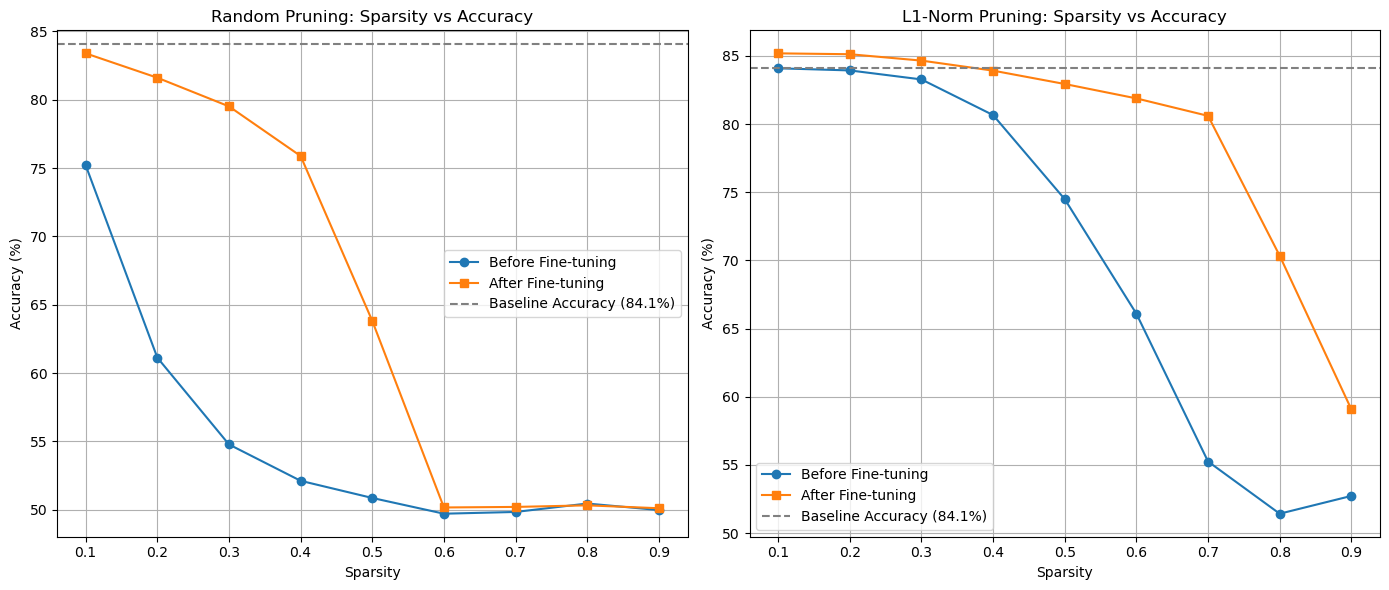

In [33]:
import matplotlib.pyplot as plt
# Baseline (unpruned) accuracy for reference.
baseline_accuracy = 84.1

df_random = df[df["method"] == "random"]
df_l1 = df[df["method"] == "l1-norm"]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Random pruning: sparsity vs. accuracy (before and after fine-tuning)
axs[0].plot(df_random["sparsity"], df_random["accuracy_before"],
            marker='o', label='Before Fine-tuning')
axs[0].plot(df_random["sparsity"], df_random["accuracy_after"],
            marker='s', label='After Fine-tuning')
axs[0].axhline(y=baseline_accuracy, color='gray', linestyle='--',
               label=f'Baseline Accuracy ({baseline_accuracy}%)')
axs[0].set_xlabel('Sparsity')
axs[0].set_ylabel('Accuracy (%)')
axs[0].set_title('Random Pruning: Sparsity vs Accuracy')
axs[0].legend()
axs[0].grid(True)

# L1-Norm pruning: sparsity vs. accuracy (before and after fine-tuning)

axs[1].plot(df_l1["sparsity"], df_l1["accuracy_before"],
            marker='o', label='Before Fine-tuning')
axs[1].plot(df_l1["sparsity"], df_l1["accuracy_after"],
            marker='s', label='After Fine-tuning')
axs[1].axhline(y=baseline_accuracy, color='gray', linestyle='--',
               label=f'Baseline Accuracy ({baseline_accuracy}%)')
axs[1].set_xlabel('Sparsity')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_title('L1-Norm Pruning: Sparsity vs Accuracy')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.savefig("combined_pruning_results.png")
plt.show()

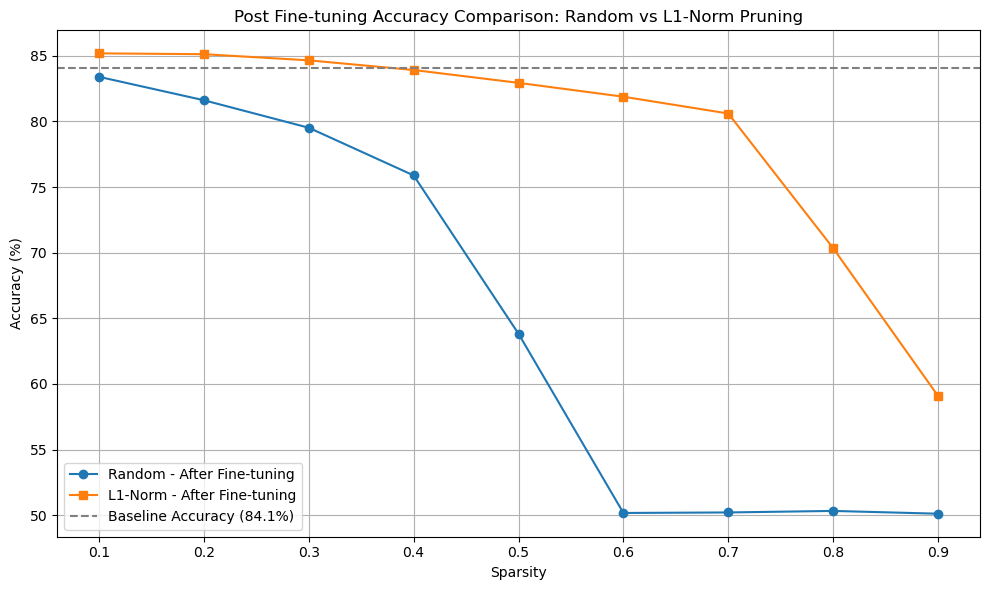

In [ ]:
# Comparison: Retrained (post fine-tuning) accuracy for Random vs L1-Norm.
plt.figure(figsize=(10, 6))
plt.plot(df_random["sparsity"], df_random["accuracy_after"], marker='o', label='Random - After Fine-tuning')
plt.plot(df_l1["sparsity"], df_l1["accuracy_after"], marker='s', label='L1-Norm - After Fine-tuning')
plt.axhline(y=baseline_accuracy, color='gray', linestyle='--',
            label=f'Baseline Accuracy ({baseline_accuracy}%)')
plt.xlabel('Sparsity')
plt.ylabel('Accuracy (%)')
plt.title('Post Fine-tuning Accuracy Comparison: Random vs L1-Norm Pruning')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pruning_comparison.png")
plt.show()

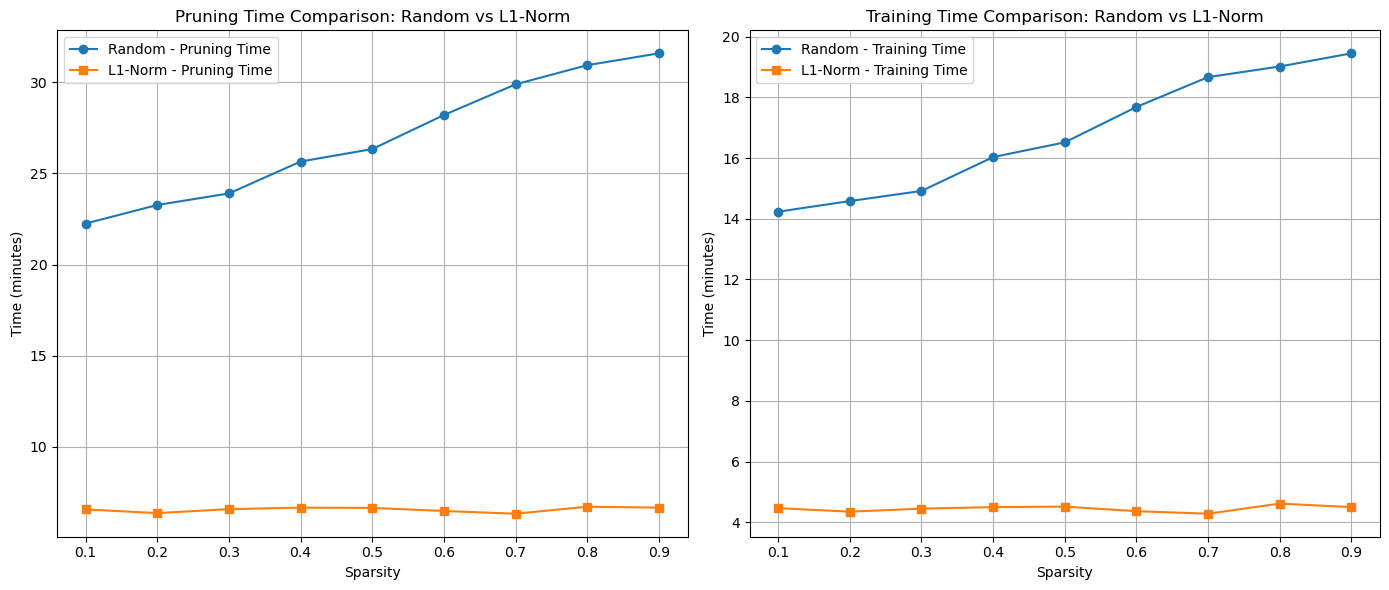

In [34]:
timing_data = {
    "pruning_time": ["22:15", "23:16", "23:54", "25:39", "26:20", "28:12", "29:53", "30:56", "31:35",
                     "06:34", "06:22", "06:35", "06:40", "06:39", "06:29", "06:20", "06:43", "06:40"],
    "training_time": ["14:14", "14:35", "14:55", "16:02", "16:31", "17:41", "18:40", "19:01", "19:27",
                      "04:28", "04:21", "04:27", "04:30", "04:31", "04:22", "04:17", "04:37", "04:30"]
}

def time_to_seconds(time_str):
    minutes, seconds = map(int, time_str.split(":"))
    return minutes * 60 + seconds


timing_df = pd.DataFrame(timing_data)
timing_df["pruning_time_sec"] = timing_df["pruning_time"].apply(time_to_seconds)
timing_df["training_time_sec"] = timing_df["training_time"].apply(time_to_seconds)

df["pruning_time_sec"] = timing_df["pruning_time_sec"]
df["training_time_sec"] = timing_df["training_time_sec"]

# Split data by method
df_random_time = df[df["method"] == "random"]
df_l1_time = df[df["method"] == "l1-norm"]

# Create a single wide figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Pruning Time Comparison
axes[0].plot(df_random_time["sparsity"], df_random_time["pruning_time_sec"] / 60, marker='o', label='Random - Pruning Time')
axes[0].plot(df_l1_time["sparsity"], df_l1_time["pruning_time_sec"] / 60, marker='s', label='L1-Norm - Pruning Time')
axes[0].set_xlabel('Sparsity')
axes[0].set_ylabel('Time (minutes)')
axes[0].set_title('Pruning Time Comparison: Random vs L1-Norm')
axes[0].legend()
axes[0].grid(True)

# Plot Training Time Comparison
axes[1].plot(df_random_time["sparsity"], df_random_time["training_time_sec"] / 60, marker='o', label='Random - Training Time')
axes[1].plot(df_l1_time["sparsity"], df_l1_time["training_time_sec"] / 60, marker='s', label='L1-Norm - Training Time')
axes[1].set_xlabel('Sparsity')
axes[1].set_ylabel('Time (minutes)')
axes[1].set_title('Training Time Comparison: Random vs L1-Norm')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("timing_comparison.png")
plt.show()

In [29]:
csv_filename = "pruning_results.csv"
df.to_csv(csv_filename, index=False)
print(f"\nResults exported to {csv_filename}")


Results exported to pruning_results.csv
